# Linear Regression Build using Gradient Descent Algorithm.

---

In [1]:
import time

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [2]:
data = pd.read_csv("house_prices_preprocessed.csv")

In [3]:
data.drop(columns=['Unnamed: 0'], inplace=True)

## Train-Test-Split:

In [16]:
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Batch Gradient Descent:

In [6]:
class GDRegressor:

    def __init__(self, learning_rate, max_iter):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.intercept = None
        self.coef = None
        self.loss = []

    def fit(self, X_train , y_train):

        self.X_train = X_train
        self.y_train = y_train

        self.intercept = 0
        self.coef = np.zeros(self.X_train.shape[1])

        for i in range(self.max_iter):

            y_pred = np.dot(self.X_train, self.coef) + self.intercept
            
            slope_coef = (-2 / self.X_train.shape[0]) * (np.dot(self.X_train.T, (self.y_train - y_pred)))
            self.coef = self.coef - (self.learning_rate * slope_coef)

            slope_intercept = -2 * (np.mean(self.y_train - y_pred))
            self.intercept = self.intercept - (self.learning_rate * slope_intercept)


            loss = np.mean((self.y_train - y_pred)**2)
            self.loss.append(loss)

    def predict(self, X_test):

        return self.intercept + np.dot(X_test, self.coef)

In [7]:
GD = GDRegressor(learning_rate = 0.01, max_iter = 500)

start_time = time.time()
GD.fit(X_train, y_train)
end_time = time.time() - start_time

print("Model Trained Succesfully!")
print(f"Time Taken for Training: {end_time:.2f}s")

Model Trained Succesfully!
Time Taken for Training: 0.33s


In [8]:
y_pred = GD.predict(X_test)

print(f"r2 Score: {(r2_score(y_test, y_pred)*100):.2f}%")
print(f"\nmean absolute error: {(mean_absolute_percentage_error(y_test, y_pred)*100):.2f}%")

r2 Score: 80.33%

mean absolute error: 9.15%


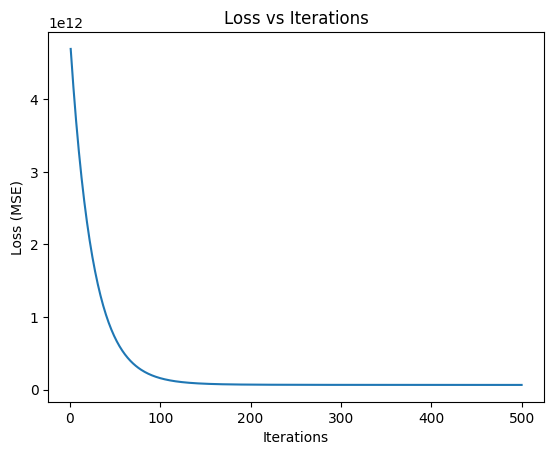

In [9]:
plt.plot(range(1, len(GD.loss) + 1), GD.loss)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Iterations")
plt.show()

## Stochastic Gradient Descent:

In [12]:
class SGDRegressor:

    def __init__(self, learning_rate, max_iter):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.intercept = None
        self.coef = None
        self.loss = []

    def fit(self, X_train , y_train):

        self.X_train = X_train
        self.y_train = y_train

        self.intercept = 0
        self.coef = np.zeros(self.X_train.shape[1])

        for i in range(self.max_iter):

            row = np.random.randint(0, self.X_train.shape[0])

            y_pred_row = self.intercept + np.dot(self.X_train[row], self.coef)

            slope_coef = -2 * (self.X_train[row] * (self.y_train.iloc[row] - y_pred_row)) 
            self.coef = self.coef - (self.learning_rate * slope_coef)

            slope_intercept = -2 * (self.y_train.iloc[row] - y_pred_row)
            self.intercept = self.intercept - (self.learning_rate * slope_intercept)

            y_pred = self.intercept + np.dot(self.X_train, self.coef)
            loss = np.mean((self.y_train - y_pred)**2)
            self.loss.append(loss)

    def predict(self, X_test):

        return self.intercept + np.dot(X_test, self.coef)

In [13]:
SGD = SGDRegressor(learning_rate = 0.01, max_iter = 500)

start_time = time.time()
SGD.fit(X_train, y_train)  
end_time = time.time() - start_time

print("Model Trained Succesfully!")
print(f"Time Taken for Training: {end_time:.2f}s")

Model Trained Succesfully!
Time Taken for Training: 0.43s


In [14]:
y_pred = SGD.predict(X_test)

print(f"r2 Score: {(r2_score(y_test, y_pred)*100):.2f}%")
print(f"\nmean absolute error: {(mean_absolute_percentage_error(y_test, y_pred)*100):.2f}%")

r2 Score: 80.74%

mean absolute error: 9.66%


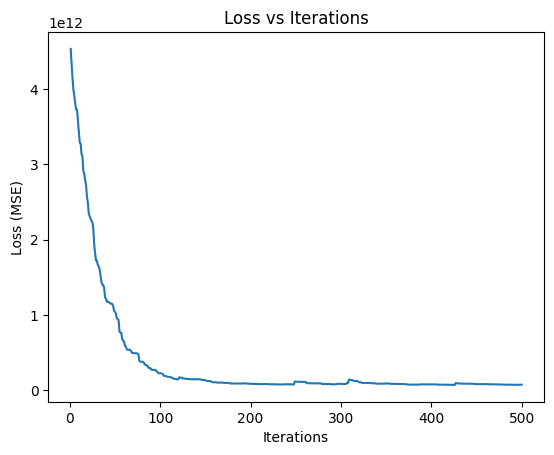

In [15]:
plt.plot(range(1, len(SGD.loss) + 1), SGD.loss)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Iterations")
plt.show()

## Mini Batch Gradient Descent:

In [18]:
import random

class MBGDRegressor:

    def __init__(self, learning_rate, max_iter, batch_size):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.intercept = None
        self.coef = None
        self.loss = []

    def fit(self, X_train, y_train):

        self.X_train = X_train
        self.y_train = y_train

        self.intercept = 0
        self.coef = np.zeros(self.X_train.shape[1])

        for i in range(self.max_iter):

            rows = random.sample(range(self.X_train.shape[0]), self.batch_size)

            y_pred_rows = self.intercept + np.dot(self.X_train[rows], self.coef)
            
            slope_coef = (-2 / self.batch_size) * (np.dot(self.X_train[rows].T, (self.y_train.iloc[rows] - y_pred_rows)))
            self.coef = self.coef - (self.learning_rate * slope_coef)

            slope_intercept = (-2 / self.batch_size) * (np.sum(self.y_train.iloc[rows] - y_pred_rows))
            self.intercept = self.intercept - (self.learning_rate * slope_intercept)

            y_pred = self.intercept + np.dot(self.X_train, self.coef)
            loss = np.mean((self.y_train - y_pred)**2)
            self.loss.append(loss)

    def predict(self, X_test):

        return self.intercept + np.dot(X_test, self.coef)

In [19]:
MBGD = MBGDRegressor(learning_rate = 0.01, max_iter = 500, batch_size=100)

start_time = time.time()
MBGD.fit(X_train, y_train)
end_time = time.time() - start_time

print("Model Trained Succesfully!")
print(f"Time Taken for Training: {end_time:.2f}s")

Model Trained Succesfully!
Time Taken for Training: 0.90s


In [20]:
y_pred = MBGD.predict(X_test)

print(f"r2 Score: {(r2_score(y_test, y_pred)*100):.2f}%")
print(f"\nmean absolute error: {(mean_absolute_percentage_error(y_test, y_pred)*100):.2f}%")

r2 Score: 80.46%

mean absolute error: 9.31%


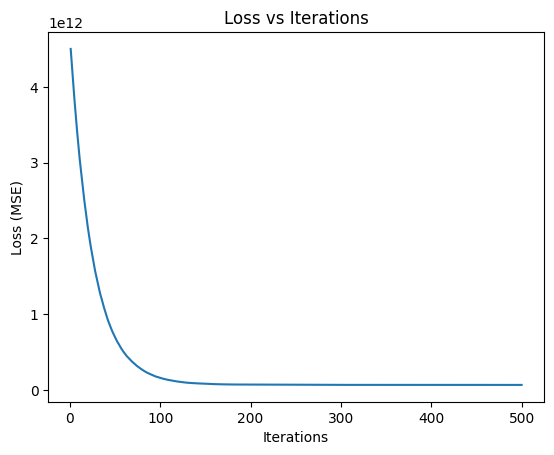

In [21]:
plt.plot(range(1, len(MBGD.loss) + 1), MBGD.loss)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Iterations")
plt.show()